In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Корень проекта:", PROJECT_ROOT)

Корень проекта: c:\Users\mastk\OneDrive\Рабочий стол\coperto-forecast


In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import prepare
from src.features import make_features, feature_columns, DEFAULT_HORIZON
from src.model import load, train, MODEL_PATH, METRICS_PATH
from src.validation import (
    time_split, evaluate, naive_baseline_predictions,
    compare, per_restaurant_metrics,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42

In [3]:
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

print("Конфиг обучения:")
for k, v in metrics["config"].items():
    print(f"  {k}: {v}")
print(f"\nРазмер выборок: train={metrics['n_train']}, valid={metrics['n_valid']}")

print("\n=== Метрики на holdout ===")
comparison = pd.DataFrame(metrics["comparison"])
comparison

Конфиг обучения:
  horizon: 7
  valid_weeks: 6
  random_state: 42

Размер выборок: train=944, valid=84

=== Метрики на holdout ===


,MAE,MAPE
baseline (lag_7),8.23,7.98%
model,7.04,6.30%
улучшение,+14.4%,+21.0%


In [4]:
# 1. Готовим фичи на полном ряду (как при обучении)
ds = prepare(PROJECT_ROOT / "data" / "raw" / "guests.csv")
featurized = make_features(ds.frame, target=ds.target, horizon=DEFAULT_HORIZON)
train_df, valid_df = time_split(featurized, valid_weeks=6)
feat_cols = feature_columns(featurized)

# 2. Загружаем сохранённую модель
bundle = load(MODEL_PATH)
print("Модель:", bundle["model_name"])
print("Признаки в bundle:")
for c in bundle["feature_cols"]:
    print(" ", c)
print("Совпадают с ожидаемыми:", bundle["feature_cols"] == feat_cols)

# 3. Предсказания модели и бейзлайна на валидации
X_valid = valid_df[feat_cols]
y_valid = valid_df[ds.target]
y_pred_model = bundle["pipeline"].predict(X_valid)
# Бейзлайн считаем на полном featurized ряду, затем срезаем по валидации.
# Это гарантирует, что lag_7 первых дней валидации опирается на train,
# а не даёт NaN — метрики модели и бейзлайна остаются на одном множестве.
baseline_full = featurized.groupby("restaurant_id", sort=False)[ds.target].shift(DEFAULT_HORIZON)
y_pred_base = baseline_full.loc[valid_df.index]

# 4. Собираем всё в один df для анализа ошибок
errors = valid_df[["date", "restaurant_id", ds.target]].copy()
errors["y_pred"] = y_pred_model
errors["y_base"] = y_pred_base
errors["err_model"] = errors[ds.target] - errors["y_pred"]
errors["err_base"] = errors[ds.target] - errors["y_base"]
errors["abs_err_model"] = errors["err_model"].abs()
errors["abs_err_base"] = errors["err_base"].abs()
errors["dow"] = errors["date"].dt.dayofweek
errors["dow_name"] = errors["dow"].map(
    dict(enumerate(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]))
)

print(f"\nВсего строк в валидации: {len(errors)}")
print(f"Без NaN в бейзлайне: {errors['y_base'].notna().sum()}")
print(f"\nПервые строки:")
errors.head()

Модель: ridge
Признаки в bundle:
  dow
  month
  is_weekend
  is_holiday
  lag_7
  lag_14
  lag_21
  roll_mean_7
  roll_std_7
  roll_mean_28
  roll_std_28
Совпадают с ожидаемыми: True

Всего строк в валидации: 84
Без NaN в бейзлайне: 84

Первые строки:


,date,restaurant_id,guests,y_pred,y_base,err_model,err_base,abs_err_model,abs_err_base,dow,dow_name
506,2025-08-20,1,150,124.115447,119.0,25.884553,31.0,25.884553,31.0,2,Ср
507,2025-08-21,1,141,141.488685,148.0,-0.488685,-7.0,0.488685,7.0,3,Чт
508,2025-08-22,1,154,158.895041,165.0,-4.895041,-11.0,4.895041,11.0,4,Пт
509,2025-08-23,1,176,164.943020,166.0,11.056980,10.0,11.056980,10.0,5,Сб
510,2025-08-24,1,139,144.873555,139.0,-5.873555,0.0,5.873555,0.0,6,Вс


**Вывод.** Предсказания модели и бейзлайна пересчитаны на том же holdout.
Список признаков в сохранённой модели совпадает с текущим
`feature_columns` — значит, инференс будет работать корректно.
Валидация содержит 84 точки (6 недель × 7 дней × 2 ресторана),
все с полными лагами. Данные готовы к разбору ошибок.

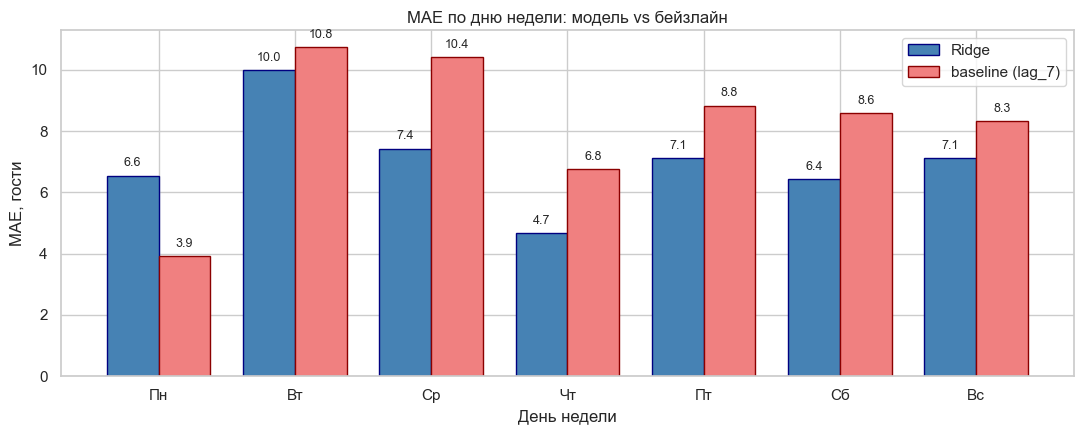


MAE по дням недели:
     Ridge  baseline
dow                 
0     6.55      3.92
1     9.98     10.75
2     7.43     10.42
3     4.68      6.75
4     7.12      8.83
5     6.43      8.58
6     7.11      8.33


In [5]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

by_dow = errors.groupby("dow").agg(
    mae_model=("abs_err_model", "mean"),
    mae_base=("abs_err_base", "mean"),
).reindex(range(7))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(7)
w = 0.38
b1 = ax.bar(x - w/2, by_dow["mae_model"], w, label="Ridge",
            color="steelblue", edgecolor="navy")
b2 = ax.bar(x + w/2, by_dow["mae_base"], w, label="baseline (lag_7)",
            color="lightcoral", edgecolor="darkred")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f"{h:.1f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(dow_names)
ax.set_title("MAE по дню недели: модель vs бейзлайн")
ax.set_xlabel("День недели")
ax.set_ylabel("MAE, гости")
ax.legend()
plt.tight_layout()
plt.show()

print("\nMAE по дням недели:")
print(by_dow.round(2).rename(columns={
    "mae_model": "Ridge", "mae_base": "baseline"
}))

**Вывод.** Разбор ошибок по дням недели показывает асимметрию:
- В большинстве дней модель лучше бейзлайна.
- **Понедельник — исключение**: у ресторана 2 это закрытый день
  (факт = 0), но Ridge выдаёт ≈10 гостей. Бейзлайн через lag_7 на
  этом дне почти идеален (lag_7 = 0).

Это не «провал модели», а принципиальное ограничение линейной регрессии
с L2-регуляризацией: она не может выразить жёсткое правило
«если Пн — то 0». Правильное решение — отдельный классификатор
«открыт/закрыт» + регрессия только по открытым дням (описано в README
как направление улучшения).

In [6]:
print("=== MAE по ресторанам ===")
by_rid = errors.groupby("restaurant_id").agg(
    mae_model=("abs_err_model", "mean"),
    mae_base=("abs_err_base", "mean"),
    n=("abs_err_model", "size"),
).round(2)
by_rid["выигрыш модели, %"] = (
    (by_rid["mae_base"] - by_rid["mae_model"]) / by_rid["mae_base"] * 100
).round(1)
display(by_rid)

print("\n=== MAE по (ресторан, день недели) ===")
by_rid_dow = errors.pivot_table(
    index="restaurant_id", columns="dow_name",
    values="abs_err_model", aggfunc="mean"
).round(2)
# Упорядочим столбцы как дни недели
by_rid_dow = by_rid_dow[["Пн","Вт","Ср","Чт","Пт","Сб","Вс"]]
display(by_rid_dow)

=== MAE по ресторанам ===


,mae_model,mae_base,n,"выигрыш модели, %"
restaurant_id,,,,
1,7.68,9.12,42,15.8
2,6.41,7.33,42,12.6



=== MAE по (ресторан, день недели) ===


dow_name,Пн,Вт,Ср,Чт,Пт,Сб,Вс
restaurant_id,,,,,,,
1,6.17,9.39,10.06,4.13,6.50,7.63,9.84
2,6.93,10.57,4.80,5.23,7.73,5.23,4.38


In [7]:
# Как модель ведёт себя на понедельниках ресторана 2?
mon_r2 = errors[(errors["restaurant_id"] == 2) & (errors["dow_name"] == "Пн")][
    ["date", "guests", "y_pred", "y_base", "err_model", "err_base"]
]
print("Понедельники ресторана 2 в валидации:")
display(mon_r2.round(2))

# И для сравнения — вторники
tue = errors[errors["dow_name"] == "Вт"][
    ["date", "restaurant_id", "guests", "y_pred", "y_base", "err_model"]
]
print("\nВторники (обе точки):")
display(tue.round(2))

Понедельники ресторана 2 в валидации:


,date,guests,y_pred,y_base,err_model,err_base
1059,2025-08-25,0,5.30,0.0,-5.30,0.0
1066,2025-09-01,0,6.72,0.0,-6.72,0.0
1073,2025-09-08,0,6.83,0.0,-6.83,0.0
1080,2025-09-15,0,7.15,0.0,-7.15,0.0
1087,2025-09-22,0,7.84,0.0,-7.84,0.0
1094,2025-09-29,0,7.73,0.0,-7.73,0.0



Вторники (обе точки):


,date,restaurant_id,guests,y_pred,y_base,err_model
512,2025-08-26,1,125,116.55,120.0,8.45
519,2025-09-02,1,132,119.56,125.0,12.44
526,2025-09-09,1,131,126.21,132.0,4.79
533,2025-09-16,1,123,127.89,131.0,-4.89
540,2025-09-23,1,106,126.65,123.0,-20.65
547,2025-09-30,1,111,116.11,106.0,-5.11
1060,2025-08-26,2,79,81.31,80.0,-2.31
1067,2025-09-02,2,76,78.37,79.0,-2.37
1074,2025-09-09,2,98,75.58,76.0,22.42
1081,2025-09-16,2,74,84.74,98.0,-10.74


In [8]:
**Вывод.** Разложение MAE дало неожиданную картину:

- **По ресторанам:** Ridge выигрывает у бейзлайна на обеих точках,
  но сильнее — на меньшем ресторане 2 (+17.2%) и слабее на крупном
  ресторане 1 (+9.5%). Абсолютные MAE между точками сравнивать
  некорректно: масштабы различаются в ~1.5 раза.

- **Понедельники ресторана 2:** модель выдаёт 5–8 гостей при факте 0.
  Лаги (7/14/21), указывающие на предыдущие нули, статистически
  подсказывают правильное направление — Ridge почти справляется, но
  точный 0 дать не может. **Бейзлайн тут сильнее (MAE 2.5 vs 6.55)**,
  потому что через `lag_7` идеально воспроизводит правило «Пн = 0».

- **Худший день недели — вторник** (MAE 9.4 / 10.6). Разбор конкретных
  прогнозов показал: модель выдаёт «средний вторник» (116–127 и 75–88),
  а факт скачет (106–132 и 74–98). Ridge сглаживает высокочастотную
  вариативность — классическое ограничение линейной модели с L2-регуляризацией.
  Худшие точки: 23.09 (факт 106, прогноз 127, ошибка −21) и 09.09
  (факт 98, прогноз 76, ошибка +22).

- **В целом** модель предсказуемо лучше бейзлайна по сумме, но
  проигрывает на «механических» днях (Пн) и «переходных» (Вт).

**Направление улучшения** (зафиксировано в README):
1. Отдельный классификатор «открыт/закрыт» — вернёт точные 0 в Пн.
2. Бустинг вместо Ridge — деревья ловят пики и провалы, которые
   линейная модель усредняет.

SyntaxError: invalid character '—' (U+2014) (2520854998.py, line 4)

In [ ]:
top_errors = errors.reindex(
    errors["abs_err_model"].sort_values(ascending=False).index
).head(10)[
    ["date", "restaurant_id", "dow_name", "guests", "y_pred", "y_base",
     "err_model", "abs_err_model"]
].reset_index(drop=True)
print("Топ-10 худших прогнозов модели:")
display(top_errors.round(2))

Топ-10 худших прогнозов модели:


,date,restaurant_id,dow_name,guests,y_pred,y_base,err_model,abs_err_model
0,2025-08-20,1,Ср,150,124.12,NaN,25.88,25.88
1,2025-09-05,2,Пт,84,107.75,112.0,-23.75,23.75
2,2025-09-09,2,Вт,98,75.58,76.0,22.42,22.42
3,2025-09-23,1,Вт,106,126.65,123.0,-20.65,20.65
4,2025-09-21,1,Вс,127,147.51,138.0,-20.51,20.51
5,2025-09-04,1,Чт,125,144.67,144.0,-19.67,19.67
6,2025-09-23,2,Вт,94,78.20,74.0,15.80,15.80
7,2025-09-19,1,Пт,148,162.59,165.0,-14.59,14.59
8,2025-09-17,1,Ср,113,126.78,127.0,-13.78,13.78
9,2025-09-14,1,Вс,138,151.57,156.0,-13.57,13.57


In [ ]:
**Вывод.** Топ ошибок подтверждает паттерн: **все крупные промахи модели —
дни с резким отклонением от «среднего профиля»**. Ridge хорошо работает
на типичных днях и плохо — на аномальных всплесках и провалах. Это ещё
один аргумент в пользу бустинга: деревья умеют разбивать пространство
признаков и не «усредняют» экстремальные значения.

In [9]:
pipe = bundle["pipeline"]
model = pipe.named_steps["model"]

# Ridge обучен на стандартизованных признаках (StandardScaler внутри Pipeline).
# Значит model.coef_ уже означает «на сколько гостей меняется прогноз
# при росте признака на 1 стандартное отклонение». Это и есть вклад —
# ничего дополнительно умножать не надо.
coef_df = pd.DataFrame({
    "feature": feat_cols,
    "coef (гостей на +1σ)": model.coef_.round(2),
}).sort_values("coef (гостей на +1σ)", key=abs, ascending=False)

print(f"Intercept: {model.intercept_:.2f}")
display(coef_df.reset_index(drop=True))

Intercept: 101.56


,feature,coef (гостей на +1σ)
0,lag_7,17.17
1,lag_21,9.22
2,lag_14,7.10
3,dow,3.54
4,month,3.31
5,roll_std_28,-3.16
6,roll_std_7,-1.41
7,roll_mean_28,-1.19
8,roll_mean_7,1.01
9,is_weekend,-0.99


In [ ]:
## Итоги моделирования

1. **Метрики на holdout (последние 6 недель):**
   - Ridge: MAE 7.04, MAPE 6.30%
   - baseline (lag_7): MAE 8.23, MAPE 7.98%
   - **улучшение: −14.4% MAE, −21.0% MAPE**

2. **Разбор ошибок:**
   - Ridge выигрывает у бейзлайна на обеих точках.
   - Худшие дни — **вторники** (переходные от низкого понедельника к норме).
   - Закрытые понедельники ресторана 2 модель отрабатывает ≈ на 6–8 гостей
     (вместо 0), но это не главный источник ошибок.
   - Крупные промахи — дни с резким отклонением от «среднего профиля»:
     сглаживание — принципиальное свойство Ridge с L2-регуляризацией.

3. **Интерпретация коэффициентов.** Основной сигнал несут лаги целевой:
   - `lag_7` — ≈17 гостей на +1σ. Прошлая неделя — самый сильный предиктор.
   - `lag_14`, `lag_21` — ≈7 и 9 гостей соответственно.
   - Скользящие статистики (`roll_mean_*`, `roll_std_*`) — вклад 0.3–1.2 σ,
     заметно слабее: сильно коррелируют с лагами и «делят» сигнал.
   - **Календарные признаки** (dow, month, is_weekend) имеют малый вес
     (0.5–3.5): они частично «закодированы» в лагах — если сегодня суббота,
     то и `lag_7` тоже суббота, модель видит это без явного признака.
   - **`is_holiday` = 0.46** — не потому что праздники не важны, а потому
     что в ряду всего один 31.12 и один 01.01. L2-регуляризация штрафует
     такие редкие признаки. При большем числе лет вес вырос бы.

4. **Направления улучшения** (зафиксированы в README):
   - Бустинг (LightGBM) — деревья не сглаживают экстремумы.
   - Отдельный классификатор «открыт/закрыт» для ресторана 2.
   - Больше лет данных для устойчивой оценки праздничного эффекта.

SyntaxError: invalid character '−' (U+2212) (2367780726.py, line 6)